In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import holidays

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

## 1. load & inpect data

In [3]:
df_2024 = pd.read_csv("monthly_hourly_load_values_2024.csv", sep="\t")
df_2025 = pd.read_csv("monthly_hourly_load_values_2025.csv", sep="\t")

df = pd.concat([df_2024,df_2025], axis = 0).sort_values("DateUTC").reset_index(drop=True)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 552264 entries, 0 to 552263
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   MeasureItem       552264 non-null  str    
 1   DateUTC           552264 non-null  str    
 2   DateShort         552264 non-null  str    
 3   TimeFrom          552264 non-null  str    
 4   TimeTo            552264 non-null  str    
 5   CountryCode       552264 non-null  str    
 6   Cov_ratio         552264 non-null  int64  
 7   Value             552264 non-null  float64
 8   Value_ScaleTo100  552264 non-null  float64
 9   CreateDate        552264 non-null  str    
 10  UpdateDate        552264 non-null  str    
dtypes: float64(2), int64(1), str(8)
memory usage: 46.3 MB


In [5]:
df

,MeasureItem,DateUTC,DateShort,TimeFrom,TimeTo,CountryCode,Cov_ratio,Value,Value_ScaleTo100,CreateDate,UpdateDate
0,Monthly Hourly Load Values,01-01-2024 00:00,01-01-2024,00:00,01:00,AL,100,731.00,731.00,03-03-2025 12:24:13,03-03-2025 12:24:13
1,Monthly Hourly Load Values,01-01-2024 00:00,01-01-2024,00:00,01:00,LU,100,402.99,402.99,03-03-2025 12:24:13,03-03-2025 12:24:13
2,Monthly Hourly Load Values,01-01-2024 00:00,01-01-2024,00:00,01:00,LV,100,652.00,652.00,03-03-2025 12:24:13,03-03-2025 12:24:13
3,Monthly Hourly Load Values,01-01-2024 00:00,01-01-2024,00:00,01:00,MD,100,488.00,488.00,03-03-2025 12:24:13,03-03-2025 12:24:13
4,Monthly Hourly Load Values,01-01-2024 00:00,01-01-2024,00:00,01:00,ME,100,307.91,307.91,03-03-2025 12:24:13,03-03-2025 12:24:13
...,...,...,...,...,...,...,...,...,...,...,...
552259,Monthly Hourly Load Values,31-12-2024 23:00,31-12-2024,23:00,00:00,DE,100,47447.03,47447.03,03-03-2025 12:24:13,03-03-2025 12:24:13
552260,Monthly Hourly Load Values,31-12-2024 23:00,31-12-2024,23:00,00:00,BA,100,1275.70,1275.70,03-03-2025 12:24:13,03-03-2025 12:24:13
552261,Monthly Hourly Load Values,31-12-2024 23:00,31-12-2024,23:00,00:00,SI,100,1161.36,1161.36,03-03-2025 12:24:13,03-03-2025 12:24:13
552262,Monthly Hourly Load Values,31-12-2024 23:00,31-12-2024,23:00,00:00,RS,100,4626.00,4626.00,03-03-2025 12:24:13,03-03-2025 12:24:13


In [6]:
df = df.loc[df["CountryCode"] == "SE"]

In [7]:
df

,MeasureItem,DateUTC,DateShort,TimeFrom,TimeTo,CountryCode,Cov_ratio,Value,Value_ScaleTo100,CreateDate,UpdateDate
13,Monthly Hourly Load Values,01-01-2024 00:00,01-01-2024,00:00,01:00,SE,100,16763.0,16763.0,03-03-2025 12:24:13,03-03-2025 12:24:13
41,Monthly Hourly Load Values,01-01-2024 01:00,01-01-2024,01:00,02:00,SE,100,16597.0,16597.0,03-03-2025 12:24:13,03-03-2025 12:24:13
99,Monthly Hourly Load Values,01-01-2024 02:00,01-01-2024,02:00,03:00,SE,100,16374.0,16374.0,03-03-2025 12:24:13,03-03-2025 12:24:13
116,Monthly Hourly Load Values,01-01-2024 03:00,01-01-2024,03:00,04:00,SE,100,16406.0,16406.0,03-03-2025 12:24:13,03-03-2025 12:24:13
170,Monthly Hourly Load Values,01-01-2024 04:00,01-01-2024,04:00,05:00,SE,100,16592.0,16592.0,03-03-2025 12:24:13,03-03-2025 12:24:13
...,...,...,...,...,...,...,...,...,...,...,...
552111,Monthly Hourly Load Values,31-12-2024 19:00,31-12-2024,19:00,20:00,SE,100,17876.0,17876.0,03-03-2025 12:24:13,03-03-2025 12:24:13
552139,Monthly Hourly Load Values,31-12-2024 20:00,31-12-2024,20:00,21:00,SE,100,17327.0,17327.0,03-03-2025 12:24:13,03-03-2025 12:24:13
552157,Monthly Hourly Load Values,31-12-2024 21:00,31-12-2024,21:00,22:00,SE,100,16624.0,16624.0,03-03-2025 12:24:13,03-03-2025 12:24:13
552223,Monthly Hourly Load Values,31-12-2024 22:00,31-12-2024,22:00,23:00,SE,100,16083.0,16083.0,03-03-2025 12:24:13,03-03-2025 12:24:13


In [8]:
df["timestamp"] = pd.to_datetime(df["DateUTC"],format="%d-%m-%Y %H:%M")
df["energy_usage"] = df["Value"]

df = df[["timestamp","energy_usage"]].sort_values("timestamp").reset_index(drop=True)

In [9]:
# ----- CHECK FOR DUPLICATE TIMESTAMPS -----
duplicates = df[df["timestamp"].duplicated(keep=False)]
print(f"Duplicate timestamps: {df['timestamp'].duplicated().sum()}")

if not duplicates.empty:
    print("\nDuplicate rows:")
    print(duplicates)
    df = df.drop_duplicates(subset="timestamp", keep="first")
    print("\nDuplicates removed (kept first occurrence).")

# ----- CHECK FOR GAPS IN THE TIME SERIES -----
expected_range = pd.date_range(
    start=df["timestamp"].min(),
    end=df["timestamp"].max(),
    freq="h"
)

missing_timestamps = expected_range.difference(df["timestamp"])
print(f"\nExpected timesteps : {len(expected_range):,}")
print(f"Actual timesteps   : {len(df):,}")
print(f"Missing timestamps : {len(missing_timestamps)}")

if len(missing_timestamps) > 0:
    print("\nSample of missing timestamps:")
    print(missing_timestamps[:10])
    df = (
        df.set_index("timestamp")
          .reindex(expected_range)
          .interpolate(method="linear")
          .rename_axis("timestamp")
          .reset_index()
    )
    print("\nGaps filled with linear interpolation.")

Duplicate timestamps: 1

Duplicate rows:
               timestamp  energy_usage
2162 2024-03-31 03:00:00       12548.0
2163 2024-03-31 03:00:00       12738.0

Duplicates removed (kept first occurrence).

Expected timesteps : 15,336
Actual timesteps   : 15,335
Missing timestamps : 1

Sample of missing timestamps:
DatetimeIndex(['2024-03-31 02:00:00'], dtype='datetime64[us]', freq='h')

Gaps filled with linear interpolation.


In [ ]:
df.loc[2162,"timestamp"] = pd.to_datetime("2024-03-31 02:00:00")

## 2. EDA

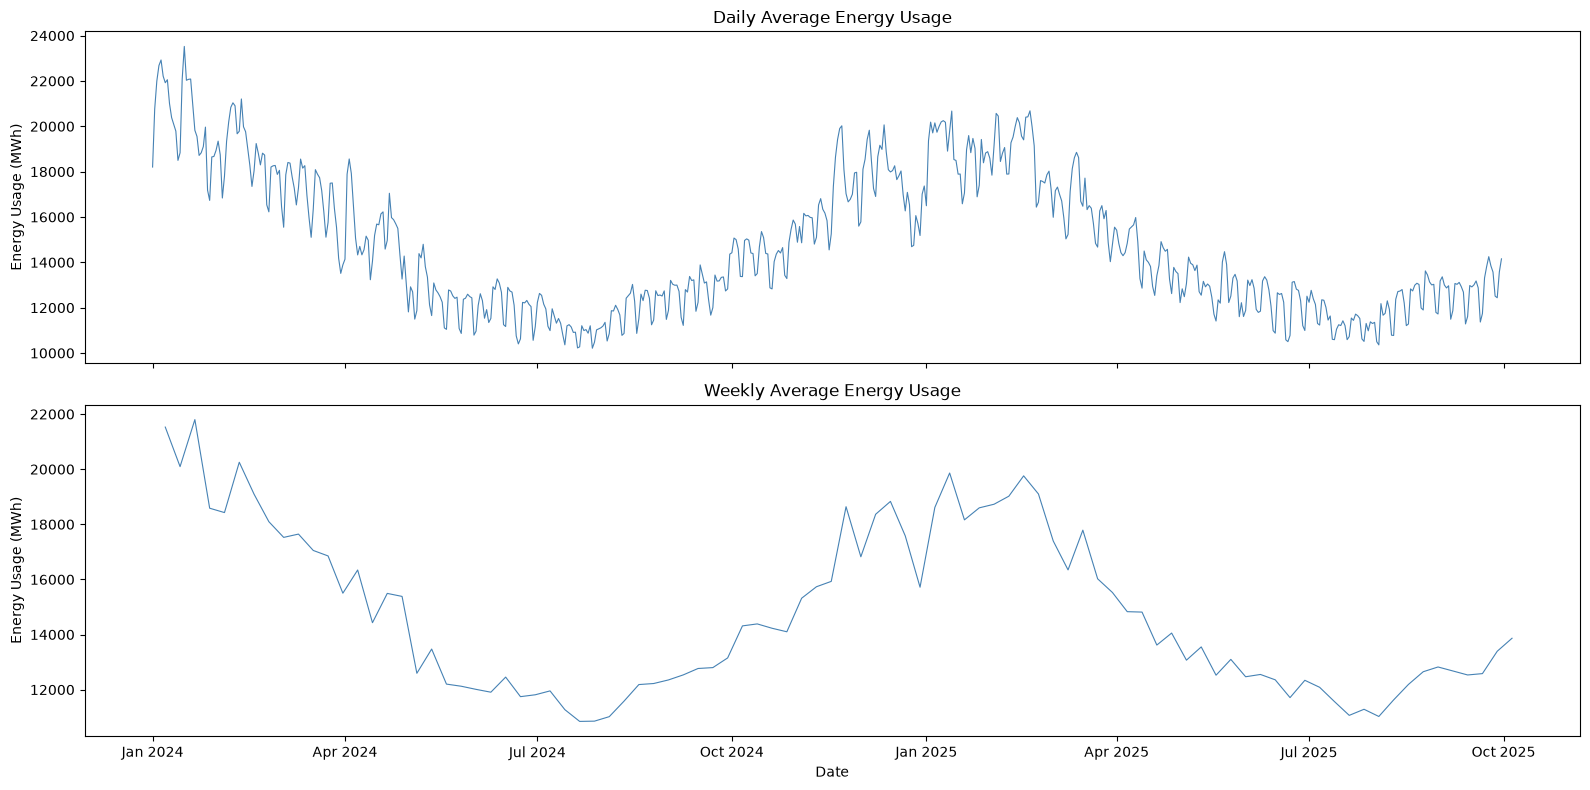

In [11]:
# Resample to daily and weekly to see trends more clearly
df_daily = df.set_index("timestamp").resample("D").mean().reset_index()
df_weekly = df.set_index("timestamp").resample("W").mean().reset_index()
fig, ax = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
ax[0].plot(df_daily["timestamp"], df_daily["energy_usage"], linewidth=0.8, color="steelblue")
ax[0].set_title("Daily Average Energy Usage", fontsize=12)
ax[0].set_ylabel("Energy Usage (MWh)")
ax[1].plot(df_weekly["timestamp"], df_weekly["energy_usage"], linewidth=0.8, color="steelblue")
ax[1].set_title("Weekly Average Energy Usage", fontsize=12)
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Energy Usage (MWh)")
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.show()

In [13]:
# ----- ADD TIME FEATURES FOR EDA -----
df["hour"]    = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.dayofweek   # 0=Monday, 6=Sunday
df["month"]   = df["timestamp"].dt.month

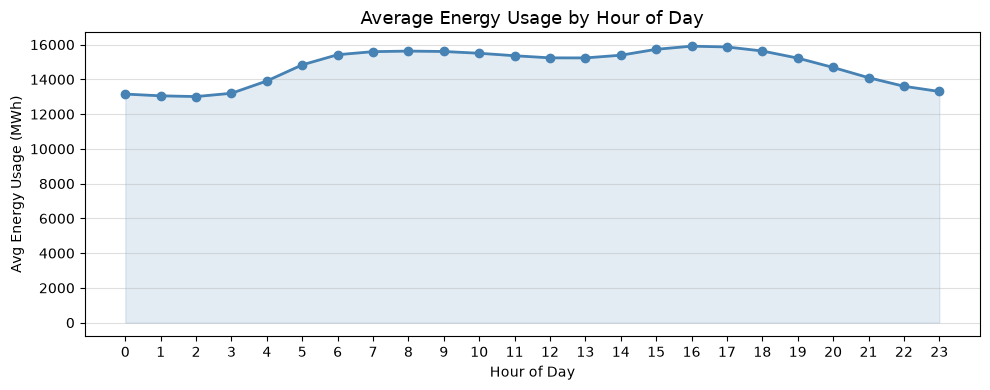

In [15]:
hourly_avg = df.groupby("hour")["energy_usage"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_avg.index, hourly_avg.values, marker="o", color="steelblue", linewidth=2)
ax.fill_between(hourly_avg.index, hourly_avg.values, alpha=0.15, color="steelblue")
ax.set_title("Average Energy Usage by Hour of Day", fontsize=13)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Avg Energy Usage (MWh)")
ax.set_xticks(range(0, 24))
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

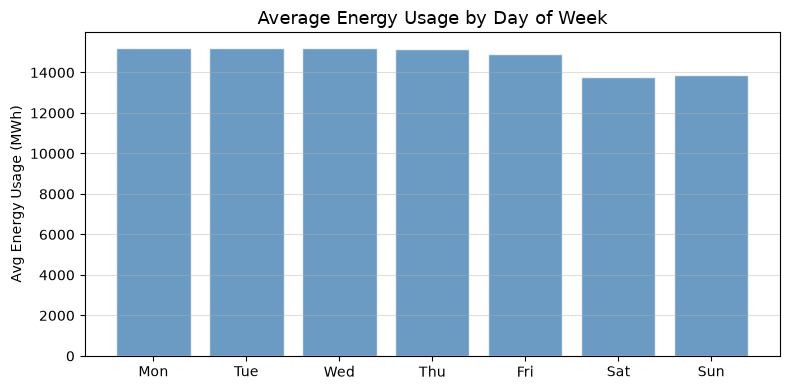

In [16]:
# ----- WEEKLY PATTERN -----
weekday_avg = df.groupby("weekday")["energy_usage"].mean()
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(day_names, weekday_avg.values, color="steelblue", alpha=0.8, edgecolor="white")
ax.set_title("Average Energy Usage by Day of Week", fontsize=13)
ax.set_ylabel("Avg Energy Usage (MWh)")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

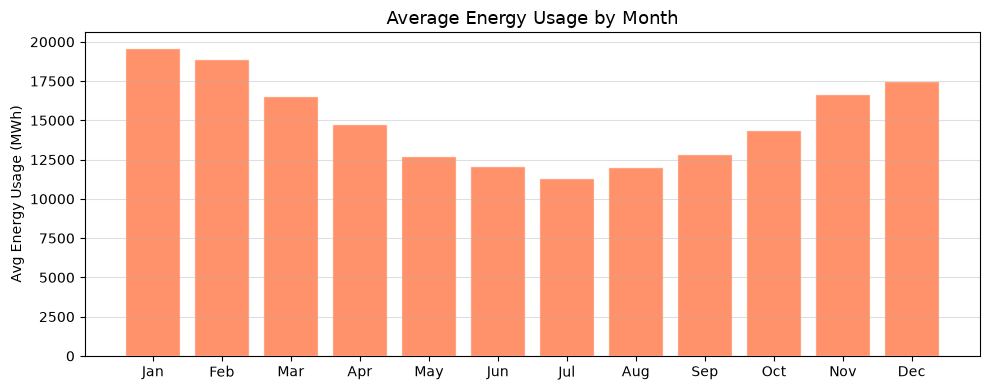

In [17]:
# ----- MONTHLY PATTERN (Seasonality) -----
monthly_avg = df.groupby("month")["energy_usage"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([month_names[m-1] for m in monthly_avg.index],
       monthly_avg.values, color="coral", alpha=0.85, edgecolor="white")
ax.set_title("Average Energy Usage by Month", fontsize=13)
ax.set_ylabel("Avg Energy Usage (MWh)")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_93945/989986156.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df["energy_usage"], vert=True, patch_artist=True,


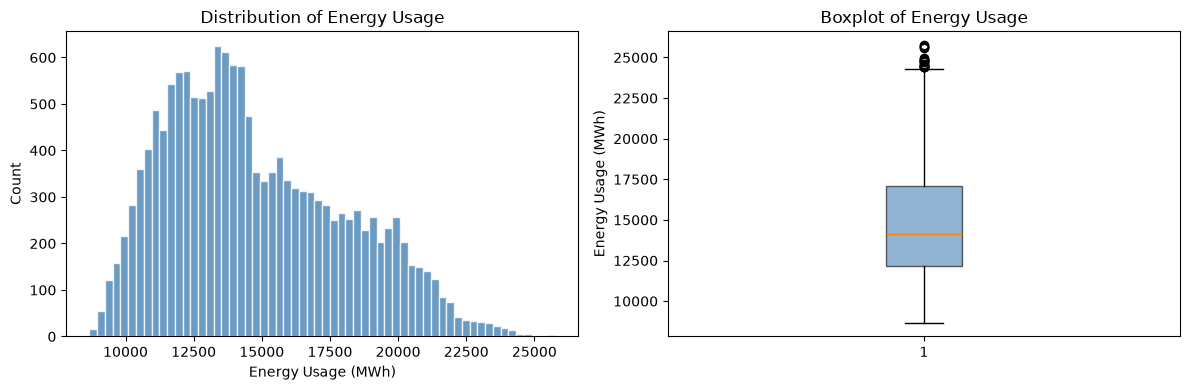

In [18]:
# ----- DISTRIBUTION -----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["energy_usage"], bins=60, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].set_title("Distribution of Energy Usage")
axes[0].set_xlabel("Energy Usage (MWh)")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["energy_usage"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_title("Boxplot of Energy Usage")
axes[1].set_ylabel("Energy Usage (MWh)")

plt.tight_layout()
plt.show()

## 3. Split into train / validation / test data

In [21]:
val_start = pd.Timestamp("2025-01-01")
test_start = pd.Timestamp("2025-07-01")

train_df = df[df["timestamp"] < val_start].copy()
val_df = df[(df["timestamp"] >= val_start) & (df["timestamp"] < test_start)].copy()
test_df = df[df["timestamp"] >= test_start].copy()

print(f"Train : {len(train_df):,} samples  ({train_df['timestamp'].min().date()} → {train_df['timestamp'].max().date()})")
print(f"Val   : {len(val_df):,} samples  ({val_df['timestamp'].min().date()} → {val_df['timestamp'].max().date()})")
print(f"Test  : {len(test_df):,} samples  ({test_df['timestamp'].min().date()} → {test_df['timestamp'].max().date()})")

Train : 8,784 samples  (2024-01-01 → 2024-12-31)
Val   : 4,344 samples  (2025-01-01 → 2025-06-30)
Test  : 2,208 samples  (2025-07-01 → 2025-09-30)


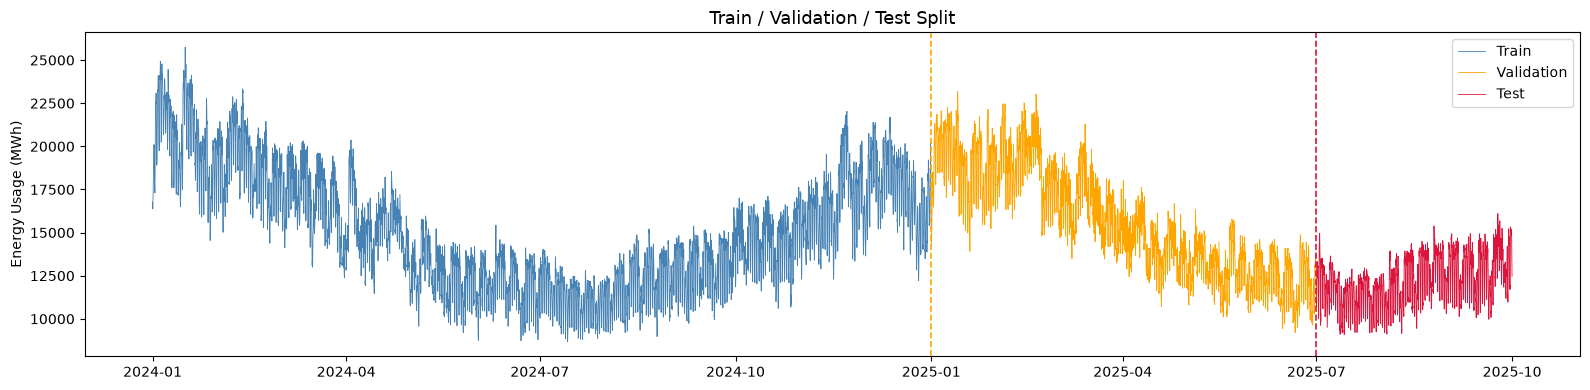

In [22]:
# ----- VISUALISE THE SPLIT -----
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(train_df["timestamp"], train_df["energy_usage"], color="steelblue", linewidth=0.6, label="Train")
ax.plot(val_df["timestamp"],   val_df["energy_usage"],   color="orange",    linewidth=0.6, label="Validation")
ax.plot(test_df["timestamp"],  test_df["energy_usage"],  color="crimson",   linewidth=0.6, label="Test")
ax.axvline(val_start,  color="orange", linestyle="--", linewidth=1.2)
ax.axvline(test_start, color="crimson", linestyle="--", linewidth=1.2)
ax.set_title("Train / Validation / Test Split", fontsize=13)
ax.set_ylabel("Energy Usage (MWh)")
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# Normalize data, ONLY fir scaler to training data to avoid leakage
scaler = StandardScaler()

train_values = scaler.fit_transform(train_df[["energy_usage"]]).flatten()
val_values = scaler.transform(val_df[["energy_usage"]]).flatten()
test_values = scaler.transform(test_df[["energy_usage"]]).flatten()

print(f"Train mean: {train_values.mean():.4f}, std: {train_values.std():.4f}")
print(f"Val mean: {val_values.mean():.4f}, std: {val_values.std():.4f}")


Train mean: 0.0000, std: 1.0000
Val mean: 0.1687, std: 0.9166


In [24]:
# ----- DEFINE FORECASTING PARAMETERS -----

# --- Sequence settings ---
# Each training sample uses SEQ_LEN past hours as input to predict the next PRED_LEN hours.
SEQ_LEN  = 168   # Look-back window: 1 week of hourly data, covers daily and weekly cycles
PRED_LEN = 24    # Forecast horizon: predict the next 24 hours (1 day ahead)

# --- Training settings ---
BATCH_SIZE    = 32     # Number of sequences processed before each weight update
LEARNING_RATE = 1e-3   # Step size for the optimizer (1e-3 is the standard Adam default)
EPOCHS        = 20     # Maximum number of full passes over the training data

# --- Model architecture ---
LSTM_UNITS = 64    # Hidden units per LSTM layer; higher = more capacity, but slower and more prone to overfitting
DROPOUT    = 0.2   # Fraction of units randomly dropped during training to reduce overfitting

# Print a quick summary of the forecasting setup
print(f"Look-back window : {SEQ_LEN} hours ({SEQ_LEN // 24} days)")
print(f"Forecast horizon : {PRED_LEN} hours ({PRED_LEN // 24} day)")

Look-back window : 168 hours (7 days)
Forecast horizon : 24 hours (1 day)


In [26]:
# Create Sliding windod datasets
    # For each sample: Take SEQ_LEN as input to perdict next PRED_LEN

def make_windows(values, seq_len, pred_len):
    """conver a flat array into (X,y) """
    X, y = [],[]
    for i in range(len(values) - seq_len - pred_len + 1):
        X.append(values[i: i + seq_len])
        y.append(values[i + seq_len: i + seq_len + pred_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_windows(train_values,SEQ_LEN,PRED_LEN)
X_val, y_val = make_windows(val_values,SEQ_LEN,PRED_LEN)
X_test, y_test = make_windows(test_values,SEQ_LEN,PRED_LEN)

print(f"X_train: {X_train.shape} y_train: {y_train.shape} ")
print(f"X_val: {X_val.shape} y_train: {y_val.shape} ")
print(f"X_test: {X_test.shape} y_train: {y_test.shape} ")

X_train: (8593, 168) y_train: (8593, 24) 
X_val: (4153, 168) y_train: (4153, 24) 
X_test: (2017, 168) y_train: (2017, 24) 


In [27]:
# Reshape for lstm - keras expects shape of (samples, timesteps, features)

X_train = X_train[...,np.newaxis]
X_val = X_val[...,np.newaxis]
X_test = X_test[...,np.newaxis]

print(f"X_train after reshape : {X_train.shape} -> (samples, timestep, features")


X_train after reshape : (8593, 168, 1) -> (samples, timestep, features


## 4. 🏋️ Train the LSTM Model

### Model Architecture

```
Input  (batch, 168, 1)
   │
   ▼
LSTM layer 1  (64 units, return sequences)  ← processes the time sequence
   │
   ▼
Dropout
   │
   ▼
LSTM layer 2  (32 units)                    ← compresses to a single context vector
   │
   ▼
Dropout
   │
   ▼
Dense (24)                                  ← outputs the 24-hour forecast
```

The first LSTM sets `return_sequences=True` so it passes the full sequence to the second LSTM.
The second LSTM returns only the final hidden state (a summary of the whole sequence).[11:25 AM]# Create Sliding Window datasets
    # For each sample: Take SEQ_LEN as input to predict next PRED_LEN

def make_windows(values, seq_len, pred_len):
    """Convert a flat array into (X, y) arrays of sliding windows"""
    X, y = [], []

    for i in range(len(values) - seq_len - pred_len + 1):
        X.append(values[i: i + seq_len])
        y.append(values[i + seq_len: i + seq_len + pred_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_windows(train_values, SEQ_LEN, PRED_LEN)
X_val, y_val = make_windows(val_values, SEQ_LEN, PRED_LEN)
X_test, y_test = make_windows(test_values, SEQ_LEN, PRED_LEN)


print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}    y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")

In [28]:
# MULD LSTM MODEL

model = keras.Sequential([

    keras.Input(shape=(SEQ_LEN,1)),
    
    # First LSTM - return-sq=true passes output at every timestamp
    layers.LSTM(LSTM_UNITS, return_sequences=True),
    layers.Dropout(DROPOUT),

    # Second LSMT - return_seq = False (default) will only output last timestamp
    layers.LSTM(LSTM_UNITS, return_sequences=False),
    layers.Dropout(DROPOUT),   

    #Output layer: predicting PRED_LEN
    layers.Dense(PRED_LEN)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,480 (201.09 KB)

 Trainable params: 51,480 (201.09 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# CCOMPILE THE MODEL 

model.compile(
    optimizer= keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse", # mean squared error
    metrics=["mae"]
)

In [30]:
# CALLBACKS
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

#ReduceLROnPlateau: halve the learnin rate if val_loss stalls
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=.5,
    patience=3,
    verbose=1
)

In [31]:
#__ TRAIN_THE_MODEL__
history = model.fit(X_train,y_train,
                    validation_data=(X_val,y_val),
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    callbacks=[early_stopping,reduce_lr],
                    verbose=1
                    )

Epoch 1/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.2424 - mae: 0.3849 - val_loss: 0.1218 - val_mae: 0.2725 - learning_rate: 0.0010
Epoch 2/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 0.1256 - mae: 0.2760 - val_loss: 0.1051 - val_mae: 0.2523 - learning_rate: 0.0010
Epoch 3/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.1080 - mae: 0.2552 - val_loss: 0.0931 - val_mae: 0.2369 - learning_rate: 0.0010
Epoch 4/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.0985 - mae: 0.2429 - val_loss: 0.0893 - val_mae: 0.2292 - learning_rate: 0.0010
Epoch 5/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 0.0931 - mae: 0.2362 - val_loss: 0.0858 - val_mae: 0.2272 - learning_rate: 0.0010
Epoch 6/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 0.0880 - mae: 0.2293 - val_loss: 0.0773 - val_mae: 0.2123 - learning_rate: 0.0010
Epoch 7/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.0831 - mae: 0.2230 - val_loss: 0.0740 - val_mae: 0.2118 - learning_rate: 0.

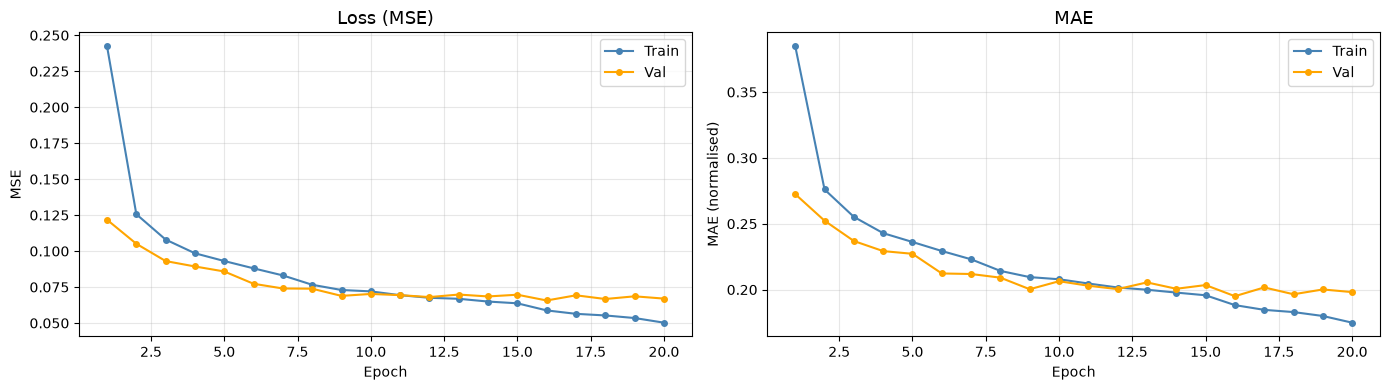

In [32]:
# ----- PLOT TRAINING CURVES -----
epochs_ran = len(history.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss (MSE)
axes[0].plot(range(1, epochs_ran+1), history.history["loss"],     label="Train", color="steelblue", marker="o", markersize=4)
axes[0].plot(range(1, epochs_ran+1), history.history["val_loss"], label="Val",   color="orange",    marker="o", markersize=4)
axes[0].set_title("Loss (MSE)", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(range(1, epochs_ran+1), history.history["mae"],     label="Train", color="steelblue", marker="o", markersize=4)
axes[1].plot(range(1, epochs_ran+1), history.history["val_mae"], label="Val",   color="orange",    marker="o", markersize=4)
axes[1].set_title("MAE", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (normalised)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Evaluate the Model

We evaluate on the **held-out test set** — data the model has never seen.

We report:
- **MAE** (Mean Absolute Error) — average error in MWh
- **RMSE** (Root Mean Squared Error) — penalises large errors more
- **MAPE** (Mean Absolute Percentage Error) — error as a percentage

In [34]:
# __PREDITC_ON_TEST_SET__
preds_scaled = model.predict(X_test,verbose=0)
tragets_scaled = y_test

# inverse-tranform to get back MWh sacle:
preds_inv = scaler.inverse_transform(preds_scaled.reshape(-1,1).reshape(preds_scaled.shape))
targets_inv = scaler.inverse_transform(tragets_scaled.reshape(-1,1).reshape(tragets_scaled.shape))

print(f"Predictions sahe: {preds_inv.shape} Tragets shape: {targets_inv.shape}")

Predictions sahe: (2017, 24) Tragets shape: (2017, 24)


In [38]:
## __COMPLETE_METRICS__

flat_preds = preds_inv.flatten()
flat_tragets = targets_inv.flatten()

mae = mean_absolute_error(flat_tragets,flat_preds)
rmse = np.sqrt(mean_squared_error(flat_tragets,flat_preds))
mape = np.mean(np.abs((flat_tragets - flat_preds) / (flat_tragets + 1e-8))) * 100

print("=" * 40)
print(f"MAE: {mae:.2f} MKh")
print(f"RMSE: {rmse:.2f} MKh")
print(f"MAPE: {mape:.2f} %")
print("=" * 40)

MAE: 455.74 MKh
RMSE: 600.53 MKh
MAPE: 3.76 %


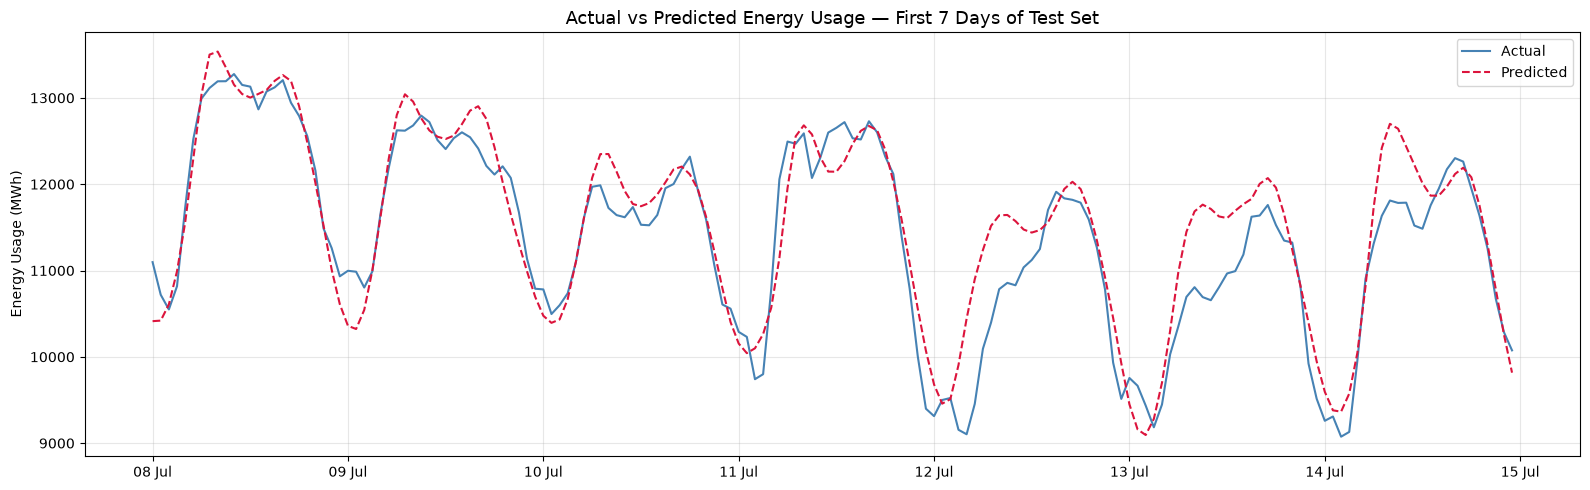

In [39]:
# ----- VISUALISE PREDICTIONS vs ACTUAL (first 7 days of test set) -----
n_show = 7 * 24   # 7 days × 24 hours

# Use the first predicted hour from each sliding window for a rolling view
rolling_preds   = preds_inv[:n_show, 0]
rolling_targets = targets_inv[:n_show, 0]

test_timestamps = test_df["timestamp"].values[SEQ_LEN : SEQ_LEN + n_show]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_timestamps, rolling_targets, label="Actual",    color="steelblue", linewidth=1.5)
ax.plot(test_timestamps, rolling_preds,   label="Predicted", color="crimson",   linewidth=1.5, linestyle="--")
ax.set_title("Actual vs Predicted Energy Usage — First 7 Days of Test Set", fontsize=13)
ax.set_ylabel("Energy Usage (MWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

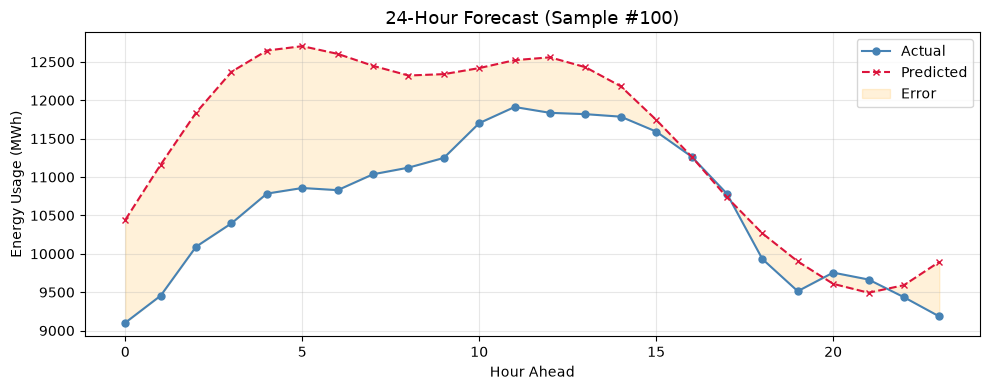

In [40]:
# ----- VISUALISE A SINGLE 24-HOUR FORECAST -----
sample_idx = 100   # Change this to look at different forecasts

pred_24h   = preds_inv[sample_idx]
target_24h = targets_inv[sample_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(24), target_24h, label="Actual",    color="steelblue", marker="o", markersize=5)
ax.plot(range(24), pred_24h,   label="Predicted", color="crimson",   marker="x", markersize=5, linestyle="--")
ax.fill_between(range(24), target_24h, pred_24h, alpha=0.15, color="orange", label="Error")
ax.set_title(f"24-Hour Forecast (Sample #{sample_idx})", fontsize=13)
ax.set_xlabel("Hour Ahead")
ax.set_ylabel("Energy Usage (MWh)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

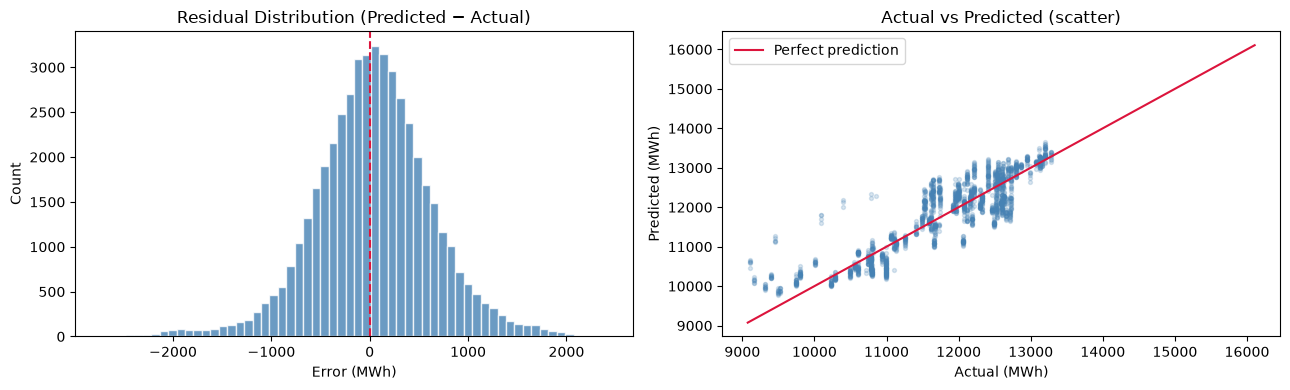

In [46]:
# ----- ERROR DISTRIBUTION -----
errors = flat_preds - flat_tragets

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(errors, bins=60, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(0, color="crimson", linewidth=1.5, linestyle="--")
axes[0].set_title("Residual Distribution (Predicted − Actual)")
axes[0].set_xlabel("Error (MWh)")
axes[0].set_ylabel("Count")

axes[1].scatter(flat_tragets[:2000], flat_preds[:2000], alpha=0.2, s=8, color="steelblue")
lim = [flat_tragets.min(), flat_tragets.max()]
axes[1].plot(lim, lim, color="crimson", linewidth=1.5, label="Perfect prediction")
axes[1].set_title("Actual vs Predicted (scatter)")
axes[1].set_xlabel("Actual (MWh)")
axes[1].set_ylabel("Predicted (MWh)")
axes[1].legend()

plt.tight_layout()
plt.show()

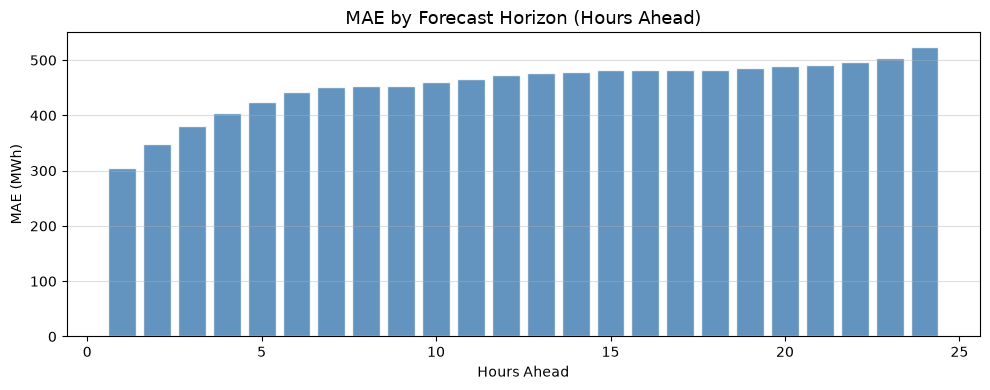

In [41]:
# ----- ERROR BY FORECAST HORIZON -----
# Does accuracy degrade as we predict further into the future?
mae_per_step = [mean_absolute_error(targets_inv[:, h], preds_inv[:, h])
                for h in range(PRED_LEN)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, PRED_LEN+1), mae_per_step, color="steelblue", alpha=0.85, edgecolor="white")
ax.set_title("MAE by Forecast Horizon (Hours Ahead)", fontsize=13)
ax.set_xlabel("Hours Ahead")
ax.set_ylabel("MAE (MWh)")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()